# Financial Inclusion Data Analysis (East Africa: 2016–2018)

This analysis explores **financial inclusion trends** across Kenya, Uganda, Tanzania, and Rwanda using survey data from 2016–2018.  
The goal is to understand **bank account ownership** and its relationship with demographic and socioeconomic factors, including:
- Location (Urban vs Rural)
- Cellphone Access
- Gender
- Education Level
- Job Type
- Household Size & Age  

Visualizations and statistical summaries are used to draw actionable insights.

### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

### 3. Load Dataset

In [3]:
#load the dataset
data = pd.read_csv('Data.csv')

### 3. Describe Data

In [4]:
# Quick look
data.head()
# Info and missing values
data.info()
data.isnull().sum()
#check the structure
data.describe()
#shape
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


(23524, 13)

### 4. Bank Account Ownership (Overall):
- **is low (14.1%)**, indicating limited financial inclusion.


bank_account
No     85.9
Yes    14.1
Name: proportion, dtype: float64


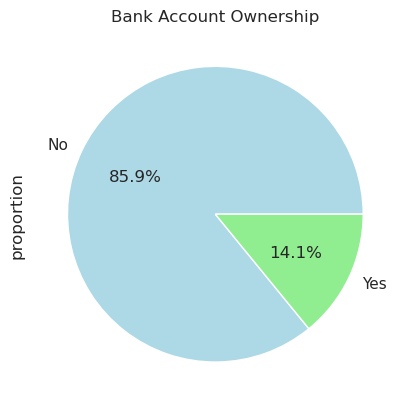

In [ ]:
# Overall ownership %
bank_pct = data['bank_account'].value_counts(normalize=True).mul(100).round(1)
print(bank_pct)

# Pie chart
bank_pct.plot.pie(autopct='%1.1f%%', colors=['lightblue','lightgreen'], title='Bank Account Ownership') # pyright: ignore[reportCallIssue]
plt.show()


### 5. Ownership by location
- Urban residents (**17.9%**) are more financially included than rural (**11.7%**).

bank_account     No   Yes
location_type            
Rural          88.3  11.7
Urban          82.1  17.9


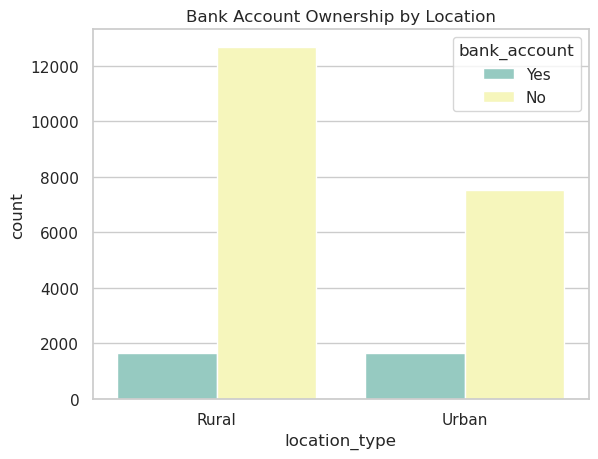

In [6]:
# Crosstab
urban_rural = pd.crosstab(data['location_type'], data['bank_account'], normalize='index').mul(100).round(1)
print(urban_rural)

# Bar chart
sns.countplot(data=data, x='location_type', hue='bank_account', palette='Set3')
plt.title("Bank Account Ownership by Location")
plt.show()

### 6. Ownership by Gender
- **Males (19%)** are nearly twice as likely as **females (10.7%)** to own bank accounts.

bank_account            No   Yes
gender_of_respondent            
Female                89.3  10.7
Male                  81.0  19.0


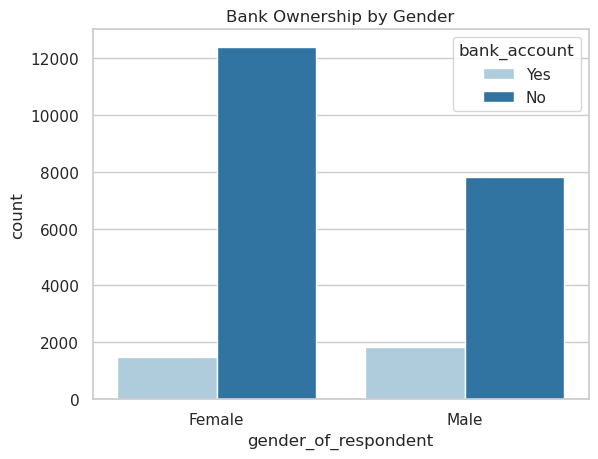

In [7]:
gender_bank = pd.crosstab(data['gender_of_respondent'], data['bank_account'], normalize='index').mul(100).round(1)
print(gender_bank)

sns.countplot(data=data, x='gender_of_respondent', hue='bank_account', palette='Paired')
plt.title("Bank Ownership by Gender")
plt.show()


### 7. Ownership by education level
- Vocational (57%) and Tertiary (51%) education lead to highest ownership.
- No formal education: only **3.9%** own accounts.


bank_account                       No   Yes
education_level                            
No formal education              96.1   3.9
Other/Dont know/RTA              68.6  31.4
Primary education                91.5   8.5
Secondary education              76.7  23.3
Tertiary education               48.9  51.1
Vocational/Specialised training  43.0  57.0


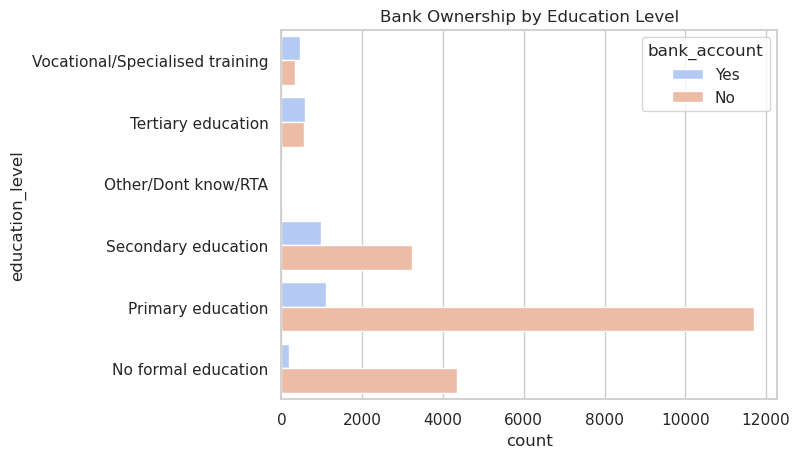

In [8]:
edu_bank = pd.crosstab(data['education_level'], data['bank_account'], normalize='index').mul(100).round(1)
print(edu_bank)

# Sorted bar chart
edu_order = edu_bank.sort_values('Yes', ascending=False).index
sns.countplot(data=data, y='education_level', hue='bank_account', order=edu_order, palette='coolwarm')
plt.title("Bank Ownership by Education Level")
plt.show()

### 8. Ownership by Job Type
- **Formal jobs (Govt: 77.5%, Private: 54%)** show higher inclusion.
- Informal, farming & no income are largely unbanked (<12%).


bank_account                    No   Yes
job_type                                
Dont Know/Refuse to answer    88.9  11.1
Farming and Fishing           88.3  11.7
Formally employed Government  22.5  77.5
Formally employed Private     45.9  54.1
Government Dependent          79.8  20.2
Informally employed           92.0   8.0
No Income                     97.9   2.1
Other Income                  81.9  18.1
Remittance Dependent          90.5   9.5
Self employed                 86.8  13.2


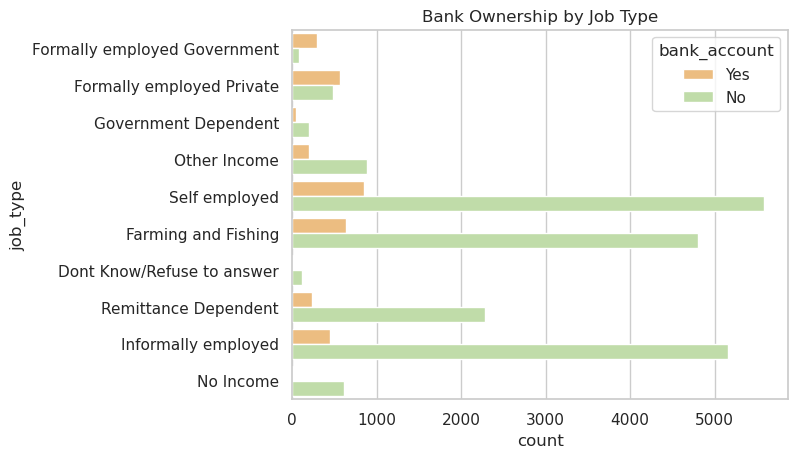

In [9]:
job_bank = pd.crosstab(data['job_type'], data['bank_account'], normalize='index').mul(100).round(1)
print(job_bank)

# Sorted horizontal bars
job_order = job_bank.sort_values('Yes', ascending=False).index
sns.countplot(data=data, y='job_type', hue='bank_account', order=job_order, palette='Spectral')
plt.title("Bank Ownership by Job Type")
plt.show()


### 9. Household size and Age
- Avg Household: **3.8 members**
- Avg Age: **38.8 years**, range 16–100.


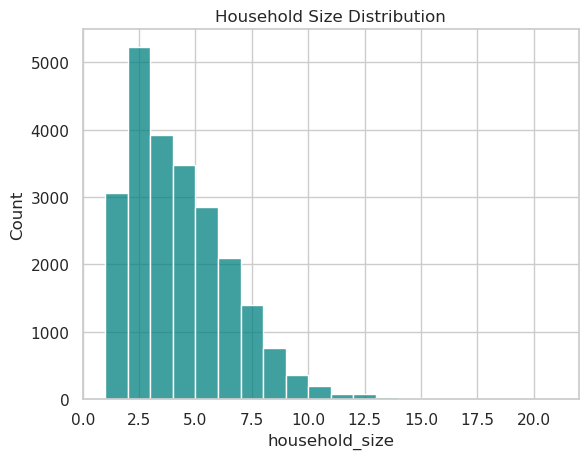

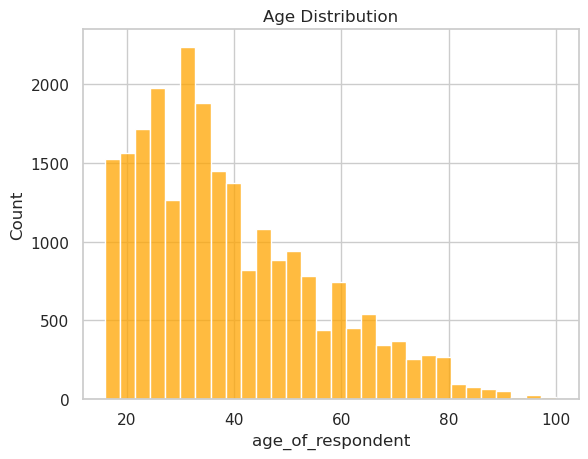

In [ ]:
# Histograms
sns.histplot(data['household_size'], bins=20, color='teal') # pyright: ignore[reportArgumentType]
plt.title("Household Size Distribution")
plt.show()

sns.histplot(data['age_of_respondent'], bins=30, color='orange') # pyright: ignore[reportArgumentType]
plt.title("Age Distribution")
plt.show()

### 10. Trend by year (2016 - 2018)
- Bank account ownership **stagnates from 2016 to 2018**, showing slow progress.

bank_account    No   Yes
year                    
2016          88.5  11.5
2017          90.8   9.2
2018          79.2  20.8


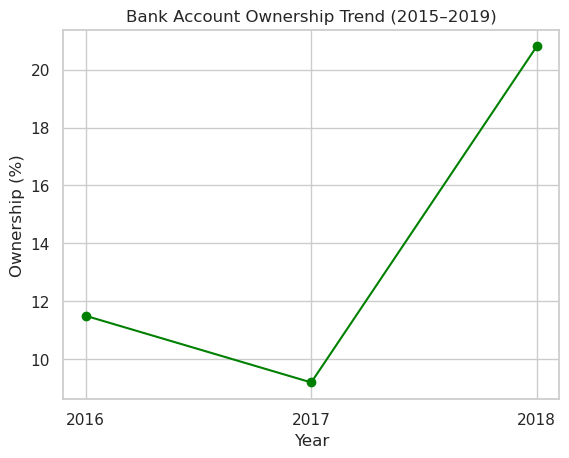

In [11]:
# Crosstab (percentages)
year_bank = pd.crosstab(data['year'], data['bank_account'], normalize='index').mul(100).round(1)
print(year_bank)

# Line chart
ax = year_bank['Yes'].plot(marker='o', color='green', title="Bank Account Ownership Trend (2015–2019)")
ax.set_ylabel("Ownership (%)")
ax.set_xlabel("Year")

# Set x-axis ticks to all years (2015–2019)
ax.set_xticks([2016, 2017, 2018])

plt.show()

### 11. Key Insights
1. Bank account ownership is **low (14.1%)**, signaling poor financial inclusion.
2. Urban, male, educated, and employed groups are more likely to be banked.
3. **Cellphone access strongly predicts inclusion**, highlighting fintech potential.
4. Rural, women, informal workers, and uneducated groups are most excluded.


## Conclusion:
Financial inclusion in East Africa remains low. Significant gaps exist by gender, location, education, and job type.

## Recommendations:
1. Expand **mobile banking & fintech** in rural areas.
2. **Gender-specific financial programs** to empower women.
3. Promote **financial literacy** via schools and community training.
4. Encourage **formal job structures** linked with banking services.
5. Support **agent banking** and simplified KYC for rural populations.
